## 1. Load MoralBERT

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd

from huggingface_hub import PyTorchModelHubMixin
from transformers import AutoModel, AutoTokenizer
from tqdm.auto import tqdm

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()
HF_TOKEN = os.getenv('HF_TOKEN')
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [4]:
MODEL_BASE = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)

class MoralBERTModel(
    nn.Module,
    PyTorchModelHubMixin,
    pipeline_tag="text-classification",
    license="mit",
):
    def __init__(self, bert_model, moral_label=2):
        super().__init__()

        self.bert = bert_model
        self.invariant_trans = nn.Linear(768, 768)
        self.moral_classification = nn.Sequential(
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Linear(768, moral_label)
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        token_type_ids=None
    ):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

        # [CLS] token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]

        pooled_output = self.invariant_trans(pooled_output)
        logits = self.moral_classification(pooled_output)

        return logits

In [ ]:
foundation = "authority"
repo_name = (
    f"vjosap/moralBERT-predict-{foundation}-in-text"
)
bert_model = AutoModel.from_pretrained(MODEL_BASE)
model = MoralBERTModel.from_pretrained(
    repo_name,
    bert_model=bert_model
)

model.to(device)
model.eval()

In [5]:
def predict_single_text(
    text: str,
    model: nn.Module,
    tokenizer,
    device: torch.device,
    max_length: int = 150
) -> float:
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = model(**encoded)
        probabilities = F.softmax(logits, dim=1)

    # 두 번째 class가 foundation present 확률
    return probabilities[0, 1].item()

In [6]:
text = "Citizens should obey legitimate laws and respect public institutions."

score = predict_single_text(
    text=text,
    model=model,
    tokenizer=tokenizer,
    device=device
)

print("authority score:", score)

authority score: 0.9965054988861084


## 2. dataset load & token count

In [1]:
import pandas as pd
df = pd.read_feather('dataset_wo_url_citation.feather')
df.head()

/Users/choejuhui/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/choejuhui/anaconda3/lib/python3.11/site-packages/pandas/io/feather_format.py:123: FutureWarning: pyarrow.feather.read_feather is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  return feather.read_feather(


,thread_id,OP,post_id,thread_size,comment_depth,is_delta,thread_pattern,ChallengerOP,comment_id,author,...,post_date,post_score,title,Topic,Title,Politicality,length_post,delta_ratio,processed_body,processed_post
0,67aa45630bc679138fd9f024,RealHonestJohn,16ra7x,1.0,1,0,C,C,67853eb0f5757a629b4e6d67,uncannylizard,...,1358439851,9,"CMV I think humanity is selfish, stupid, and s...",60,Suicide,0,16,0.0,Humanity is stupid relative to what? Are not w...,"proof: overpopulation, religion, wasting resou..."
1,67aa45630bc679138fd9f026,RealHonestJohn,16ra7x,1.0,1,0,C,C,67853eb0f5757a629b4e6d9a,sehablaespanol1104,...,1358439851,9,"CMV I think humanity is selfish, stupid, and s...",60,Suicide,0,16,0.0,"It seems like a lot of this would be normal, a...","proof: overpopulation, religion, wasting resou..."
2,67aa45630bc679138fd9f027,RealHonestJohn,16ra7x,1.0,1,0,C,C,67853eb0f5757a629b4e6f60,bert_mars,...,1358439851,9,"CMV I think humanity is selfish, stupid, and s...",60,Suicide,0,16,0.0,Civilization is a precursor to religion... Hun...,"proof: overpopulation, religion, wasting resou..."
3,67aa45630bc679138fd9f029,RealHonestJohn,16ra7x,1.0,1,0,C,C,67853eb0f5757a629b4e7554,SteampunkWolf,...,1358439851,9,"CMV I think humanity is selfish, stupid, and s...",60,Suicide,0,16,0.0,We are getting better. Slowly. Painfully slowl...,"proof: overpopulation, religion, wasting resou..."
4,67aa45630bc679138fd9f02b,ancillarynipple,16ralh,4.0,1,0,COCO,C,67853eb0f5757a629b4e6cdf,Thompson_S_Sweetback,...,1358440202,14,I think single people should get the most tax ...,21,Taxes,1,12,0.0,Long term economic disincentives will not be v...,Why should I pay higher taxes when I use less ...


In [8]:
text = """It seems like a lot of this would be normal, and is, in the society we created from hundreds and thousands of years of only knowing,  eat, survive, reproduce.  I do not know about suicidal but things like overpopulation, wasting of resources, obesity, greed, and war seem the logical conclusion in a society built by humans with an innate driving force to consume, survive, and reproduce."""

encoded = tokenizer(text, add_special_tokens=True)
token_count = len(encoded["input_ids"])

print("토큰 개수:", token_count)

토큰 개수: 83


In [ ]:
df['token_count_comment'] = df['processed_body'].apply(lambda x: len(tokenizer(x, add_special_tokens=True)["input_ids"]))
df['token_count_comment'].describe()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


count    2.062969e+06
mean     1.459231e+02
std      1.632832e+02
min      7.000000e+00
25%      4.900000e+01
50%      9.400000e+01
75%      1.810000e+02
max      2.612000e+03
Name: token_count_comment, dtype: float64

Matplotlib is building the font cache; this may take a moment.


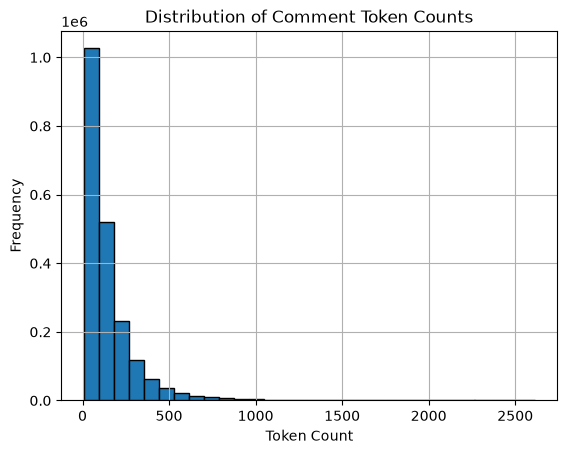

In [ ]:
import matplotlib.pyplot as plt

df["token_count_comment"].dropna().hist(
    bins=30,
    edgecolor="black"
)

plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Token Counts")
plt.show()

In [ ]:
df['length_comment'].describe()

count    2.062969e+06
mean     5.403733e+01
std      6.165479e+01
min      5.000000e+00
25%      1.700000e+01
50%      3.400000e+01
75%      6.800000e+01
max      9.970000e+02
Name: length_comment, dtype: float64

## 3. Sliding-window + max-pooling inference (150 토큰 초과 텍스트용)

위 토큰 분포에서 보이듯 75th percentile이 181 토큰으로, 상당수의 댓글이 150 토큰을 초과한다. `predict_single_text`처럼 그냥 잘라버리면(truncation) 뒷부분의 도덕적 표현이 유실될 수 있다.

대신 `stride`만큼 겹치도록 여러 청크로 나눠 각 청크를 독립적으로 추론하고, foundation-present 확률의 **최댓값(max-pooling)**을 최종 점수로 사용한다.
- mean이 아닌 max를 쓰는 이유: 도덕적 수사가 긴 댓글의 일부에만 등장해도 놓치지 않기 위함 — mean을 쓰면 중립적인 청크가 신호를 희석시켜 과소추정된다.
- 텍스트가 150 토큰 이하면 청크가 1개만 생성되므로 `predict_single_text`와 결과가 동일하다. 즉 기존 함수를 완전히 대체해도 안전하다.

In [13]:
def predict_single_text_chunked(
    text: str,
    model: nn.Module,
    tokenizer,
    device: torch.device,
    max_length: int = 150,
    stride: int = 30,
) -> float:
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        truncation=True,
        stride=stride,
        return_overflowing_tokens=True,
        padding="max_length",
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )

    # 배치 크기(=청크 개수)를 벗어난 메타데이터는 forward에 필요 없음
    encoded.pop("overflow_to_sample_mapping", None)

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        logits = model(**encoded)  # (num_chunks, 2)
        probabilities = F.softmax(logits, dim=1)

    # 청크별 foundation-present 확률 중 최댓값 (max-pooling)
    return probabilities[:, 1].max().item()


In [14]:
long_text = (
    "I went to the store yesterday and bought some groceries for the week, "
    "including bread, milk, eggs, and a few vegetables that were on sale. "
    "The weather was mild so I decided to walk instead of driving, which took "
    "about twenty minutes each way through the park near my apartment. "
    "On the way back I ran into an old coworker I hadn't seen in years and we "
    "caught up briefly before going our separate ways. "
    "Citizens should obey legitimate laws and respect public institutions, "
    "because a society without respect for authority quickly descends into chaos "
    "and undermines the trust that holds communities together. "
    "Anyway, once I got home I put everything away and started cooking dinner, "
    "which ended up taking longer than expected because I couldn't find the recipe "
    "I was looking for and had to improvise with what I had on hand."
)

encoded_len = len(tokenizer(long_text, add_special_tokens=True)["input_ids"])
print("토큰 개수:", encoded_len)

score_truncated = predict_single_text(
    text=long_text, model=model, tokenizer=tokenizer, device=device
)
score_chunked = predict_single_text_chunked(
    text=long_text, model=model, tokenizer=tokenizer, device=device
)

print("truncation만 사용:", score_truncated)
print("sliding-window + max-pooling:", score_chunked)

토큰 개수: 167
truncation만 사용: 0.9969570636749268
sliding-window + max-pooling: 0.9969570636749268


In [15]:
tqdm.pandas(desc="Predicting authority scores (sliding-window + max-pooling)")

df["authority_comment_chunked"] = df["processed_body"].progress_apply(
    lambda text: predict_single_text_chunked(
        text,
        model=model,
        tokenizer=tokenizer,
        device=device
    )
)

# 150 토큰 이하 댓글은 두 방식이 이론상 동일해야 함 (검증)
short_mask = df["token_count_comment"] <= 150
print(
    "150 토큰 이하 댓글에서 두 방식 최대 오차:",
    (df.loc[short_mask, "authority_comment"] - df.loc[short_mask, "authority_comment_chunked"]).abs().max()
)

# 150 토큰 초과 댓글에서 점수 차이가 큰 경우 확인
long_mask = ~short_mask
diff = (df.loc[long_mask, "authority_comment_chunked"] - df.loc[long_mask, "authority_comment"])
print("150 토큰 초과 댓글 개수:", long_mask.sum())
print("chunked 점수가 더 높아진 비율:", (diff > 0.05).mean())


Predicting authority scores (sliding-window + max-pooling):   0%|          | 7/2062969 [00:02<226:58:38,  2.52it/s] 


KeyboardInterrupt: 

### 왜 150 토큰대 댓글에서 truncation-only와 chunked 점수가 같게 나오는가

`predict_single_text_chunked`의 **첫 번째 청크는 `predict_single_text`가 만드는 truncated encoding과 토큰이 완전히 동일**하다 (둘 다 앞에서부터 148개 content 토큰을 사용). 따라서 max-pooling 결과는 항상 truncation-only 점수 **이상**이며, 뒤쪽 청크(꼬리 부분 + overlap)에 더 강한 신호가 없으면 두 값은 정확히 같아진다. 즉 동일한 값이 나오는 건 버그가 아니라 "이 댓글은 앞부분에 이미 가장 강한 신호가 있었다"는 뜻이다.

아래 셀에서 청크별 점수를 직접 뜯어봐서 확인할 수 있다.

In [17]:
def debug_chunk_scores(
    text: str,
    model: nn.Module,
    tokenizer,
    device: torch.device,
    max_length: int = 150,
    stride: int = 30,
) -> list[float]:
    """청크별 foundation-present 점수를 리스트로 반환 (첫 번째 값 = truncation-only 점수)"""
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        truncation=True,
        stride=stride,
        return_overflowing_tokens=True,
        padding="max_length",
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )
    encoded.pop("overflow_to_sample_mapping", None)
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded)
        probabilities = F.softmax(logits, dim=1)

    return probabilities[:, 1].tolist()


# 167 토큰 근방 댓글 몇 개를 뽑아서 청크별 점수 확인
sample = df[df["token_count_comment"].between(150, 200)].sample(5, random_state=0)

for _, row in sample.iterrows():
    scores = debug_chunk_scores(
        row["processed_body"], model=model, tokenizer=tokenizer, device=device
    )
    print(f"token_count={row['token_count_comment']}, 청크별 점수={['%.4f' % s for s in scores]}, max={max(scores):.4f}")


KeyError: 'token_count_comment'

## 4. 문장 단위(sentence-aware) chunking

지금까지의 `predict_single_text_chunked`는 토큰 개수만 보고 148개씩 기계적으로 잘랐기 때문에, 문장/절 중간이 잘릴 수 있다 (예: "stealing is wrong because..."에서 "because" 뒤가 다음 청크로 넘어감). 도덕적 수사는 보통 문장 단위로 완결되므로, **문장 경계를 지키면서** 각 청크가 150 토큰 이내가 되도록 문장을 그리디하게 묶는다.

- `nltk.sent_tokenize`로 문장을 나눈 뒤, 토큰 예산(148 = 150 - `[CLS]`/`[SEP]`)을 넘지 않는 선에서 문장을 순서대로 채워 넣는다.
- 청크 경계에서 문맥이 완전히 끊기지 않도록 `sentence_overlap`개 문장을 다음 청크 시작에 다시 포함시킨다 (토큰 단위 `stride`의 문장 버전).
- **엣지 케이스**: 문장 하나가 148토큰을 넘는 run-on sentence(쉼표만 있고 마침표가 드문 Reddit 댓글에서 실제로 나옴)는 그 문장 하나만 `_split_long_sentence`로 토큰 단위 sliding-window fallback을 적용한다. (처음엔 이 문장을 통째로 넣고 `truncation=True`에 맡기려 했는데, 그러면 뒷부분이 조용히 잘려나가는 걸 검증 중 발견해서 수정함 — 301토큰짜리 단일 문장 테스트에서 뒤 153토큰이 유실되는 걸 확인했다.)
- 집계는 이전과 동일하게 **max-pooling**을 사용한다.

In [18]:
import nltk
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize


def _split_long_sentence(
    sentence: str,
    tokenizer,
    max_length: int,
    stride: int,
) -> list[str]:
    """문장 하나가 max_length보다 긴 극단적 케이스(run-on sentence 등)를 위한 토큰 단위 fallback"""
    content_capacity = max_length - 2
    ids = tokenizer(sentence, add_special_tokens=False)["input_ids"]
    step = content_capacity - stride

    pieces = []
    i = 0
    while True:
        pieces.append(tokenizer.decode(ids[i:i + content_capacity]))
        if i + content_capacity >= len(ids):
            break
        i += step

    return pieces


def chunk_by_sentences(
    text: str,
    tokenizer,
    max_length: int = 150,
    stride: int = 30,
    sentence_overlap: int = 1,
) -> list[str]:
    """문장 경계를 지키면서 각 청크가 max_length 토큰(특수 토큰 포함) 이내가 되도록 나눈다.

    한 문장이 통째로 content_capacity를 넘는 run-on sentence는 _split_long_sentence로
    토큰 단위 sliding-window fallback을 적용해, 뒷부분이 조용히 잘려나가지 않게 한다.
    """
    content_capacity = max_length - 2  # [CLS], [SEP]

    sentences = sent_tokenize(text)
    if not sentences:
        return [text]

    sent_lens = [
        len(tokenizer(s, add_special_tokens=False)["input_ids"])
        for s in sentences
    ]

    chunks = []
    n = len(sentences)
    start = 0

    while start < n:
        # 문장 하나가 이미 capacity를 넘는 경우: 그 문장만 별도로 token-level fallback 처리
        if sent_lens[start] > content_capacity:
            chunks.extend(
                _split_long_sentence(sentences[start], tokenizer, max_length, stride)
            )
            start += 1
            continue

        end = start
        total = 0
        while (
            end < n
            and sent_lens[end] <= content_capacity
            and total + sent_lens[end] <= content_capacity
        ):
            total += sent_lens[end]
            end += 1

        chunks.append(" ".join(sentences[start:end]))

        if end >= n:
            break

        # 다음 청크는 이번 청크의 마지막 sentence_overlap개 문장부터 다시 시작 (문장 단위 overlap)
        start = max(start + 1, end - sentence_overlap)

    return chunks

[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


In [19]:
def predict_single_text_sentence_chunked(
    text: str,
    model: nn.Module,
    tokenizer,
    device: torch.device,
    max_length: int = 150,
    stride: int = 30,
    sentence_overlap: int = 1,
) -> float:
    chunks = chunk_by_sentences(
        text,
        tokenizer,
        max_length=max_length,
        stride=stride,
        sentence_overlap=sentence_overlap,
    )

    encoded = tokenizer(
        chunks,
        add_special_tokens=True,
        max_length=max_length,
        truncation=True,
        padding="max_length",
        return_attention_mask=True,
        return_token_type_ids=True,
        return_tensors="pt"
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded)  # (num_chunks, 2)
        probabilities = F.softmax(logits, dim=1)

    return probabilities[:, 1].max().item()

In [20]:
# 토큰 단위 청크 vs 문장 단위 청크가 실제로 어떻게 다르게 잘리는지 확인

print("=== 토큰 단위 sliding-window (문장 중간이 잘릴 수 있음) ===")
token_level_encoded = tokenizer(
    long_text, add_special_tokens=True, max_length=150, truncation=True,
    stride=30, return_overflowing_tokens=True
)
for i, ids in enumerate(token_level_encoded["input_ids"]):
    print(f"[chunk {i}] {tokenizer.decode(ids)}\n")

print("=== 문장 단위 chunking (문장이 끊기지 않음) ===")
for i, c in enumerate(chunk_by_sentences(long_text, tokenizer)):
    n_tokens = len(tokenizer(c, add_special_tokens=False)["input_ids"])
    print(f"[chunk {i}] ({n_tokens} tokens) {c}\n")

print("=== 최종 점수 비교 ===")
print("truncation만:               ", predict_single_text(long_text, model, tokenizer, device))
print("토큰 sliding-window + max:   ", predict_single_text_chunked(long_text, model, tokenizer, device))
print("문장 단위 chunking + max:    ", predict_single_text_sentence_chunked(long_text, model, tokenizer, device))

=== 토큰 단위 sliding-window (문장 중간이 잘릴 수 있음) ===
[chunk 0] [CLS] i went to the store yesterday and bought some groceries for the week, including bread, milk, eggs, and a few vegetables that were on sale. the weather was mild so i decided to walk instead of driving, which took about twenty minutes each way through the park near my apartment. on the way back i ran into an old coworker i hadn ' t seen in years and we caught up briefly before going our separate ways. citizens should obey legitimate laws and respect public institutions, because a society without respect for authority quickly descends into chaos and undermines the trust that holds communities together. anyway, once i got home i put everything away and started cooking dinner, which ended up taking longer than expected because i couldn ' t find the recipe [SEP]

[chunk 1] [CLS] anyway, once i got home i put everything away and started cooking dinner, which ended up taking longer than expected because i couldn ' t find the recipe 

In [25]:
df_sample = df.sample(100, random_state=0)
df_sample

,thread_id,OP,post_id,thread_size,comment_depth,is_delta,thread_pattern,ChallengerOP,comment_id,author,...,post_date,post_score,title,Topic,Title,Politicality,length_post,delta_ratio,processed_body,processed_post
1117185,67aa548c0bc679138f0cbb6e,artem_m,ma5ldy,6.0,6,0,CCOCOC,C,678544e3f5757a629bcde9e0,IeuanTemplar,...,1616359168,0,CMV: Alcoholics Anonymous is Just Converversio...,107,Alcohol,0,50,0.0,I just needed to get some perspective on my sh...,"I find the two processes remarkably similar, a..."
809764,67aa4fff0bc679138ffb6468,scottsaa,c13pqu,1.0,1,0,C,C,678542bcf5757a629ba3f381,FreeLook93,...,1560642436,10,CMV: Someone's Time is Better Spent Learning t...,151,Daylight Savings Time,0,153,0.0,"We are social animals. We, for the most part, ...","Sometimes I find that people want to hang out,..."
1086302,67aa54200bc679138f0ae24b,ligamentary,l3k2ze,1.0,1,0,C,C,678544d4f5757a629bcca6fb,babymagicals,...,1611434629,17013,CMV: Transgender women should not be allowed t...,70,Gender Gap in Sports,1,237,0.0,what about the women’s biological advantages? ...,I want to start by saying I do not intend to b...
409919,67aa4ba10bc679138fec1833,GhostOfGuyFieri,5pxz50,1.0,1,0,C,C,678540b8f5757a629b7c9a0a,FinasCupil,...,1485284345,159,"CMV:If you were eligible to vote, and didn't, ...",3,Trump and Republican Party,1,97,0.0,I pay taxes sooo...I can complain all I want.,I am no fan of Trump. But when I see people wh...
1146688,67aa54f10bc679138f0e90c5,porcipine,n79664,1.0,1,0,C,C,6785451cf5757a629bd227d2,AsIfTheyWantedTo,...,1620422065,114,CMV: People at grocery stores who pick out mea...,34,Morality of Eating Animals,0,56,0.0,Since you are coming out of the gate with such...,"When meat like ground beef, chicken breast, et..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487914,67aa4c5f0bc679138feeed27,hail_the_mole_people,6svhia,2.0,1,0,CO,C,67854114f5757a629b841989,exotics,...,1502391450,90,"CMV: If you can't parallel park, you shouldn't...",7,Cars and Driving,0,101,0.0,People who are not great at parallel parking c...,I fully understand parallel parking is not som...
1673159,67aa5c460bc679138f2ad743,andrew21w,194g66d,3.0,1,1,COD,C,678548ddf5757a629b17e56b,WeariedCape5,...,1705016275,4,CMV: The best period for me to fully come out ...,130,Casual Sex,0,161,0.5,> it will reduce my dating pool significantly ...,I am bi. I am still not out. Only two people k...
367714,67aa4b280bc679138fea7eb7,shardro,50h8yk,1.0,1,0,C,C,6785408bf5757a629b785b4e,big_face_killah,...,1472651126,931,"CMV:The argument against privacy ""I have nothi...",113,Privacy and Data,1,170,0.0,Its a valid argument I guess. Its just a reall...,Many people argue against privacy saying if yo...
30577,67aa45d90bc679138fdb5a4e,OwMyBoatingArm,1hv4rd,1.0,1,0,C,C,67853eccf5757a629b51e6ff,OnlineCourage,...,1373293109,66,"I believe that the ""collapse"" will never happe...",171,Overpopulation and Population Growth,1,154,1.0,Have you ever been to a severely under-develop...,"I used to enjoy subs like <SUBREDDIT>, <SUBRED..."


In [ ]:
from tqdm.auto import tqdm

tqdm.pandas(desc="predicting authority scores (sentence-level chunking + max-pooling)")
df_sample["authority_comment"] = df_sample["processed_body"].progress_apply(
    lambda text: predict_single_text_sentence_chunked(
        text,
        model=model,
        tokenizer=tokenizer,
        device=device
    )
)   
df_sample

predicting authority scores (sentence-level chunking + max-pooling): 100%|██████████| 100/100 [00:04<00:00, 24.18it/s]


,thread_id,OP,post_id,thread_size,comment_depth,is_delta,thread_pattern,ChallengerOP,comment_id,author,...,post_score,title,Topic,Title,Politicality,length_post,delta_ratio,processed_body,processed_post,authority_comment
1117185,67aa548c0bc679138f0cbb6e,artem_m,ma5ldy,6.0,6,0,CCOCOC,C,678544e3f5757a629bcde9e0,IeuanTemplar,...,0,CMV: Alcoholics Anonymous is Just Converversio...,107,Alcohol,0,50,0.0,I just needed to get some perspective on my sh...,"I find the two processes remarkably similar, a...",0.001069
809764,67aa4fff0bc679138ffb6468,scottsaa,c13pqu,1.0,1,0,C,C,678542bcf5757a629ba3f381,FreeLook93,...,10,CMV: Someone's Time is Better Spent Learning t...,151,Daylight Savings Time,0,153,0.0,"We are social animals. We, for the most part, ...","Sometimes I find that people want to hang out,...",0.000621
1086302,67aa54200bc679138f0ae24b,ligamentary,l3k2ze,1.0,1,0,C,C,678544d4f5757a629bcca6fb,babymagicals,...,17013,CMV: Transgender women should not be allowed t...,70,Gender Gap in Sports,1,237,0.0,what about the women’s biological advantages? ...,I want to start by saying I do not intend to b...,0.000459
409919,67aa4ba10bc679138fec1833,GhostOfGuyFieri,5pxz50,1.0,1,0,C,C,678540b8f5757a629b7c9a0a,FinasCupil,...,159,"CMV:If you were eligible to vote, and didn't, ...",3,Trump and Republican Party,1,97,0.0,I pay taxes sooo...I can complain all I want.,I am no fan of Trump. But when I see people wh...,0.001547
1146688,67aa54f10bc679138f0e90c5,porcipine,n79664,1.0,1,0,C,C,6785451cf5757a629bd227d2,AsIfTheyWantedTo,...,114,CMV: People at grocery stores who pick out mea...,34,Morality of Eating Animals,0,56,0.0,Since you are coming out of the gate with such...,"When meat like ground beef, chicken breast, et...",0.001605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487914,67aa4c5f0bc679138feeed27,hail_the_mole_people,6svhia,2.0,1,0,CO,C,67854114f5757a629b841989,exotics,...,90,"CMV: If you can't parallel park, you shouldn't...",7,Cars and Driving,0,101,0.0,People who are not great at parallel parking c...,I fully understand parallel parking is not som...,0.000858
1673159,67aa5c460bc679138f2ad743,andrew21w,194g66d,3.0,1,1,COD,C,678548ddf5757a629b17e56b,WeariedCape5,...,4,CMV: The best period for me to fully come out ...,130,Casual Sex,0,161,0.5,> it will reduce my dating pool significantly ...,I am bi. I am still not out. Only two people k...,0.000730
367714,67aa4b280bc679138fea7eb7,shardro,50h8yk,1.0,1,0,C,C,6785408bf5757a629b785b4e,big_face_killah,...,931,"CMV:The argument against privacy ""I have nothi...",113,Privacy and Data,1,170,0.0,Its a valid argument I guess. Its just a reall...,Many people argue against privacy saying if yo...,0.007187
30577,67aa45d90bc679138fdb5a4e,OwMyBoatingArm,1hv4rd,1.0,1,0,C,C,67853eccf5757a629b51e6ff,OnlineCourage,...,66,"I believe that the ""collapse"" will never happe...",171,Overpopulation and Population Growth,1,154,1.0,Have you ever been to a severely under-develop...,"I used to enjoy subs like <SUBREDDIT>, <SUBRED...",0.020242
